# Clustering algorithm comparison

In [1]:
import sys, os, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, MiniBatchKMeans, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity

from src.preprocess import load_data, get_audio_features, AUDIO_FEATURES
from src.recommender import (
    interpret_playlist, score_songs_by_audio,
    AUDIO_FEATURES as REC_AUDIO_FEATURES,
)
from src.embeddings import create_playlist_embedding
from src.evaluate import precision_at_k
from src.test_set import TEST_PLAYLISTS, HELD_OUT_PLAYLISTS, get_ground_truth_indices

OUT_DIR = ROOT / 'data' / 'cluster_comparison_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_CLUSTERS = 20
SILHOUETTE_SAMPLE = 50_000
TOP_K = 10
ALPHA = 0.9
print('Imports done.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding vibe anchors...
Vibe anchors ready.
Imports done.


## 1. Load dataset and prepare audio matrix

In [2]:
df = load_data('data/spotify_data.csv')
audio_matrix, scaler = get_audio_features(df)
text_embeddings = np.load('data/text_embeddings.npy')

rng = np.random.default_rng(RANDOM_STATE)
sil_idx = rng.choice(len(audio_matrix), size=SILHOUETTE_SAMPLE, replace=False)
sil_X = audio_matrix[sil_idx]

print(f'Songs:               {len(df):,}')
print(f'Audio matrix shape:  {audio_matrix.shape}')
print(f'Silhouette sample:   {SILHOUETTE_SAMPLE:,}')

Songs:               1,159,748
Audio matrix shape:  (1159748, 12)
Silhouette sample:   50,000


## 2. Helper functions

In [3]:
def compute_centroids(X, labels):
    return {int(c): X[labels == c].mean(axis=0)
            for c in np.unique(labels) if c >= 0}

def get_relevant_clusters_generic(target_features, scaler, centroids, top_n=3):
    feature_vec = np.array([[target_features[f] for f in REC_AUDIO_FEATURES]])
    normalized = scaler.transform(feature_vec)[0]
    cluster_ids = list(centroids.keys())
    if not cluster_ids:
        return set()
    cmat = np.array([centroids[c] for c in cluster_ids])
    d = np.linalg.norm(cmat - normalized, axis=1)
    return set(int(cluster_ids[i]) for i in d.argsort()[:top_n])

def evaluate_recommender(df_with_clusters, scaler, centroids, playlists):
    results = []
    for pl in playlists:
        interp = interpret_playlist(pl['name'])
        relevant = get_relevant_clusters_generic(interp['features'], scaler, centroids)
        year_range = interp.get('year_range')
        audio_scores = score_songs_by_audio(
            df_with_clusters, interp['features'], interp['genres'],
            relevant if relevant else None, year_range,
        )
        name_text_vec = create_playlist_embedding(pl['name'])
        text_sim = cosine_similarity(name_text_vec, text_embeddings)[0]
        text_sim_norm = (text_sim - text_sim.min()) / (text_sim.max() - text_sim.min() + 1e-8)
        final = ALPHA * audio_scores + (1 - ALPHA) * text_sim_norm
        top_idx = final.argsort()[-TOP_K:][::-1].tolist()
        truth = get_ground_truth_indices(df_with_clusters, pl)
        results.append({'playlist': pl['name'],
                        'precision@10': precision_at_k(top_idx, list(truth), TOP_K)})
    return results

def intrinsic_metrics(labels):
    sub = labels[sil_idx]
    valid = sub >= 0
    if valid.sum() < 2 or len(set(sub[valid].tolist())) < 2:
        return np.nan, np.nan, np.nan
    return (silhouette_score(sil_X[valid], sub[valid]),
            davies_bouldin_score(sil_X[valid], sub[valid]),
            calinski_harabasz_score(sil_X[valid], sub[valid]))

def run_and_report(name, fit_fn):
    print(f'\n=== {name.upper()} ===')
    t0 = time.time()
    labels = fit_fn()
    runtime = time.time() - t0
    if labels is None:
        print('  Skipped.')
        return None
    np.save(OUT_DIR / f'labels_{name}.npy', labels)
    n_clusters = int((np.unique(labels) >= 0).sum())
    n_noise = int((labels < 0).sum())
    sil, db, ch = intrinsic_metrics(labels)
    print(f'  Done in {runtime:.1f}s — {n_clusters} clusters, {n_noise:,} noise')
    print(f'  Silhouette: {sil:.4f}   Davies-Bouldin: {db:.4f}   Calinski-Harabasz: {ch:.0f}')
    df_local = df.copy()
    df_local['cluster'] = labels
    centroids = compute_centroids(audio_matrix, labels)
    dev = evaluate_recommender(df_local, scaler, centroids, TEST_PLAYLISTS)
    held = evaluate_recommender(df_local, scaler, centroids, HELD_OUT_PLAYLISTS)
    dev_mean = np.mean([r['precision@10'] for r in dev])
    held_mean = np.mean([r['precision@10'] for r in held])
    print(f'  Dev mean Precision@10:      {dev_mean:.4f}')
    print(f'  Held-out mean Precision@10: {held_mean:.4f}')
    return {
        'algorithm': name, 'n_clusters': n_clusters, 'n_noise': n_noise,
        'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch,
        'runtime_sec': runtime,
        'dev_mean': dev_mean, 'held_out_mean': held_mean,
        'dev_per_playlist': dev, 'held_out_per_playlist': held,
    }

all_results = {}
print('Helpers ready.')

Helpers ready.


## 3. K-Means  (k = 20)  — baseline

In [4]:
def fit_kmeans():
    return KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10).fit_predict(audio_matrix)

all_results['kmeans'] = run_and_report('kmeans', fit_kmeans)


=== KMEANS ===
  Done in 39.0s — 20 clusters, 0 noise
  Silhouette: 0.1217   Davies-Bouldin: 1.7717   Calinski-Harabasz: 3787
  Dev mean Precision@10:      0.8800
  Held-out mean Precision@10: 0.3533


## 4. MiniBatchKMeans  (k = 20)

In [5]:
def fit_minibatch_kmeans():
    return MiniBatchKMeans(
        n_clusters=N_CLUSTERS, random_state=RANDOM_STATE,
        batch_size=4096, n_init=5, max_iter=300,
    ).fit_predict(audio_matrix)

all_results['minibatch_kmeans'] = run_and_report('minibatch_kmeans', fit_minibatch_kmeans)


=== MINIBATCH_KMEANS ===
  Done in 1.0s — 20 clusters, 0 noise
  Silhouette: 0.1183   Davies-Bouldin: 1.7621   Calinski-Harabasz: 3702
  Dev mean Precision@10:      0.8733
  Held-out mean Precision@10: 0.3400


## 5. Gaussian Mixture Model  (k = 20, full covariance)

In [6]:
def fit_gmm():
    gmm = GaussianMixture(
        n_components=N_CLUSTERS, covariance_type='full',
        random_state=RANDOM_STATE, n_init=3, max_iter=200,
    )
    gmm.fit(audio_matrix)
    return gmm.predict(audio_matrix)

all_results['gmm'] = run_and_report('gmm', fit_gmm)


=== GMM ===
  Done in 2618.2s — 20 clusters, 0 noise
  Silhouette: -0.0033   Davies-Bouldin: 2.8003   Calinski-Harabasz: 1529
  Dev mean Precision@10:      0.8667
  Held-out mean Precision@10: 0.3533


## 6. BIRCH  (n_clusters = 20) — two-stage hybrid

In [ ]:
def fit_birch():
    birch = Birch(n_clusters=None, threshold=1.5, branching_factor=50)
    birch.fit(audio_matrix)
    centers = birch.subcluster_centers_
    print(f'  Stage 1 (BIRCH CF tree): {len(centers):,} subclusters at threshold=1.5')

    point_subcluster = birch.predict(audio_matrix)
    final = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=5).fit(centers)
    print(f'  Stage 2 (K-Means on subcluster centers): grouped into {N_CLUSTERS} final clusters')
    return final.labels_[point_subcluster]

all_results['birch'] = run_and_report('birch', fit_birch)

## 7. HDBSCAN  (auto-determined k)

In [ ]:
def fit_hdbscan():
    try:
        import hdbscan
    except ImportError:
        print('  hdbscan not installed — pip install hdbscan')
        return None
    try:
        return hdbscan.HDBSCAN(
            min_cluster_size=500, min_samples=25,
            cluster_selection_method='eom', metric='euclidean',
            algorithm='boruvka_kdtree', core_dist_n_jobs=-1,
        ).fit_predict(audio_matrix)
    except (MemoryError, Exception) as e:
        print(f'  Direct fit failed ({type(e).__name__}). Falling back to sample-and-assign.')
        sample = 100_000
        idx = rng.choice(len(audio_matrix), size=sample, replace=False)
        m = hdbscan.HDBSCAN(
            min_cluster_size=50, min_samples=10,
            metric='euclidean', algorithm='boruvka_kdtree',
            core_dist_n_jobs=-1,
        )
        sl = m.fit_predict(audio_matrix[idx])
        valid = sl >= 0
        if valid.sum() == 0:
            return None
        unique = sorted(set(sl[valid].tolist()))
        centroids = np.array([audio_matrix[idx][sl == c].mean(axis=0) for c in unique])
        from sklearn.metrics.pairwise import euclidean_distances
        out = np.empty(len(audio_matrix), dtype=int)
        chunk = 50_000
        for s in range(0, len(audio_matrix), chunk):
            e = min(s + chunk, len(audio_matrix))
            d = euclidean_distances(audio_matrix[s:e], centroids)
            out[s:e] = np.array(unique)[d.argmin(axis=1)]
        return out

all_results['hdbscan'] = run_and_report('hdbscan', fit_hdbscan)

## 8. FAISS K-Means  (k = 20)  — production-grade implementation

In [ ]:
def fit_faiss_kmeans():
    try:
        import faiss
    except ImportError:
        print('  faiss not installed — pip install faiss-cpu')
        return None

    X = np.ascontiguousarray(audio_matrix, dtype=np.float32)

    kmeans = faiss.Kmeans(
        d=X.shape[1],
        k=N_CLUSTERS,
        niter=20,
        nredo=10,
        seed=RANDOM_STATE,
        verbose=False,
    )
    kmeans.train(X)

    _, labels = kmeans.index.search(X, 1)
    return labels.flatten().astype(np.int64)

all_results['faiss_kmeans'] = run_and_report('faiss_kmeans', fit_faiss_kmeans)

## 8. Summary table

In [9]:
rows = [r for r in all_results.values() if r is not None]
summary = pd.DataFrame([{
    'algorithm': r['algorithm'],
    'n_clusters': r['n_clusters'],
    'n_noise': r['n_noise'],
    'silhouette':       round(r['silhouette'], 4),
    'davies_bouldin':   round(r['davies_bouldin'], 4),
    'calinski_harabasz':round(r['calinski_harabasz'], 0),
    'runtime_sec':      round(r['runtime_sec'], 1),
    'dev_mean_p@10':    round(r['dev_mean'], 4),
    'held_out_mean_p@10': round(r['held_out_mean'], 4),
} for r in rows])
summary.to_csv(OUT_DIR / 'summary.csv', index=False)
summary

,algorithm,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,runtime_sec,dev_mean_p@10,held_out_mean_p@10
0,kmeans,20,0,0.1217,1.7717,3787.0,39.0,0.8800,0.3533
1,minibatch_kmeans,20,0,0.1183,1.7621,3702.0,1.0,0.8733,0.3400
2,gmm,20,0,-0.0033,2.8003,1529.0,2618.2,0.8667,0.3533
3,birch,20,0,0.0919,1.9617,2165.0,356.2,0.8667,0.3533
4,hdbscan,9,26349,0.1103,2.5005,1845.0,2578.8,0.8733,0.3533


## 9. End-to-end Precision@10 bar chart

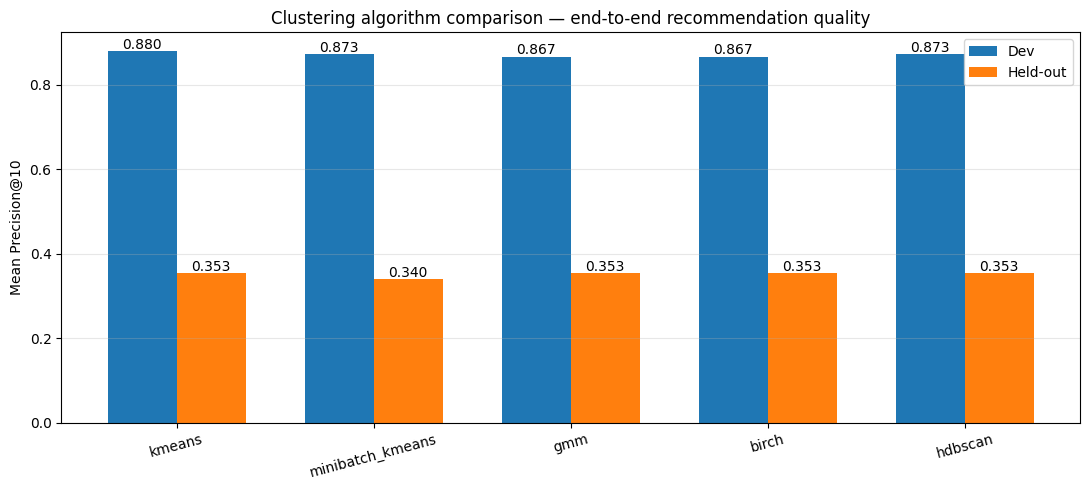

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
algos = summary['algorithm'].tolist()
x = np.arange(len(algos))
w = 0.35
ax.bar(x - w/2, summary['dev_mean_p@10'], w, label='Dev', color='#1f77b4')
ax.bar(x + w/2, summary['held_out_mean_p@10'], w, label='Held-out', color='#ff7f0e')
for i, v in enumerate(summary['dev_mean_p@10']):
    ax.text(i - w/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
for i, v in enumerate(summary['held_out_mean_p@10']):
    ax.text(i + w/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(algos, rotation=15)
ax.set_ylabel('Mean Precision@10')
ax.set_title('Clustering algorithm comparison — end-to-end recommendation quality')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'comparison_bar_chart.png', dpi=200)
plt.show()

## 10. Per-playlist breakdown

In [11]:
per_playlist_rows = []
for r in rows:
    for d in r['dev_per_playlist']:
        per_playlist_rows.append({'algorithm': r['algorithm'], 'set': 'dev', **d})
    for d in r['held_out_per_playlist']:
        per_playlist_rows.append({'algorithm': r['algorithm'], 'set': 'held_out', **d})
per_playlist_df = pd.DataFrame(per_playlist_rows)
per_playlist_df.to_csv(OUT_DIR / 'end_to_end_results.csv', index=False)

pivot_held = per_playlist_df[per_playlist_df['set'] == 'held_out'].pivot(
    index='playlist', columns='algorithm', values='precision@10'
)
pivot_held

algorithm,birch,gmm,hdbscan,kmeans,minibatch_kmeans
playlist,,,,,
Beach Vibes,0.7,0.7,0.7,0.6,0.6
Bedtime,0.9,0.8,0.9,0.9,0.9
Coffee Shop,0.0,0.0,0.0,0.0,0.0
Dance Floor,0.6,0.7,0.6,0.8,0.7
Date Night,0.0,0.0,0.0,0.0,0.0
Deep Work,0.0,0.0,0.0,0.0,0.0
Gym Beast Mode,0.7,0.9,0.7,0.7,0.7
Headbanger Anthems,0.0,0.0,0.0,0.0,0.0
Heartbreak Hour,0.8,0.6,0.8,0.8,0.8


## 11. Per-algorithm visualisations

In [ ]:
from sklearn.decomposition import PCA

ALGO_ORDER = ['kmeans', 'minibatch_kmeans', 'gmm', 'birch', 'hdbscan', 'faiss_kmeans']
ALGO_LABELS = {
    'kmeans': 'K-Means',
    'minibatch_kmeans': 'MiniBatchKMeans',
    'gmm': 'GMM',
    'birch': 'BIRCH',
    'hdbscan': 'HDBSCAN',
    'faiss_kmeans': 'FAISS K-Means',
}
labels_by_algo = {}
for a in ALGO_ORDER:
    label_path = OUT_DIR / f'labels_{a}.npy'
    if label_path.exists():
        labels_by_algo[a] = np.load(label_path)
    else:
        print(f'  Skipping {a} — no saved labels found at {label_path}')

ALGO_ORDER = [a for a in ALGO_ORDER if a in labels_by_algo]

if 'summary' not in globals():
    summary = pd.read_csv(OUT_DIR / 'summary.csv')

PCA_SAMPLE = 30_000
pca_idx = rng.choice(len(audio_matrix), size=PCA_SAMPLE, replace=False)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_xy = pca.fit_transform(audio_matrix[pca_idx])
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}  '
      f'PC2={pca.explained_variance_ratio_[1]:.3f}  '
      f'total={pca.explained_variance_ratio_.sum():.3f}')

print('Labels loaded for:', list(labels_by_algo.keys()))
print('Summary rows:', len(summary))

### 11.1 Cluster size distribution

In [ ]:
n_algos = len(ALGO_ORDER)
n_cols = 3
n_rows = (n_algos + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
for ax, algo in zip(axes, ALGO_ORDER):
    lab = labels_by_algo[algo]
    unique, counts = np.unique(lab, return_counts=True)
    order = np.argsort(-counts)
    unique = unique[order]
    counts = counts[order]
    colors = ['#cc4444' if u < 0 else '#1f77b4' for u in unique]
    ax.bar(range(len(unique)), counts, color=colors)
    ax.set_title(f'{ALGO_LABELS[algo]}  ({len(unique)} clusters, '
                 f'{int((lab < 0).sum()):,} noise)', fontsize=11)
    ax.set_xlabel('cluster (sorted by size)')
    ax.set_ylabel('songs')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)
for ax in axes[n_algos:]:
    ax.axis('off')
plt.suptitle('Cluster size distribution (log scale)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'viz_cluster_sizes.png', dpi=200, bbox_inches='tight')
plt.show()

### 11.2 PCA 2-D projection

In [ ]:
n_algos = len(ALGO_ORDER)
n_cols = 3
n_rows = (n_algos + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()
for ax, algo in zip(axes, ALGO_ORDER):
    sub_lab = labels_by_algo[algo][pca_idx]
    noise_mask = sub_lab < 0
    if noise_mask.any():
        ax.scatter(pca_xy[noise_mask, 0], pca_xy[noise_mask, 1],
                   c='lightgrey', s=2, alpha=0.4, label='noise')
    valid = ~noise_mask
    ax.scatter(pca_xy[valid, 0], pca_xy[valid, 1],
               c=sub_lab[valid], cmap='tab20', s=2, alpha=0.6)
    n_c = int((np.unique(labels_by_algo[algo]) >= 0).sum())
    ax.set_title(f'{ALGO_LABELS[algo]}  ({n_c} clusters)', fontsize=12)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
for ax in axes[n_algos:]:
    ax.axis('off')
plt.suptitle(f'PCA 2-D projection of audio features ({PCA_SAMPLE:,}-song sample)',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(OUT_DIR / 'viz_pca_projection.png', dpi=200, bbox_inches='tight')
plt.show()

### 11.3 Cluster audio-feature centroid heatmaps

In [ ]:
n_algos = len(ALGO_ORDER)
fig, axes = plt.subplots(1, n_algos, figsize=(4.4 * n_algos, 7), sharey=False)
if n_algos == 1:
    axes = [axes]
vmin, vmax = -2.0, 2.0
for ax, algo in zip(axes, ALGO_ORDER):
    lab = labels_by_algo[algo]
    cids = sorted([int(c) for c in np.unique(lab) if c >= 0])
    cmat = np.array([audio_matrix[lab == c].mean(axis=0) for c in cids])
    if len(cmat) > 1:
        row_order = np.argsort(cmat @ pca.components_[0])
        cmat = cmat[row_order]
        cids = [cids[i] for i in row_order]
    im = ax.imshow(cmat, aspect='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(AUDIO_FEATURES)))
    ax.set_xticklabels(AUDIO_FEATURES, rotation=60, ha='right', fontsize=8)
    ax.set_yticks(range(len(cids)))
    ax.set_yticklabels(cids, fontsize=7)
    ax.set_title(f'{ALGO_LABELS[algo]}  ({len(cids)} clusters)', fontsize=11)
    ax.set_ylabel('cluster id')
fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.015, pad=0.01,
             label='centroid z-score')
plt.suptitle('Cluster centroids — audio-feature profile', fontsize=14, y=1.02)
plt.savefig(OUT_DIR / 'viz_centroid_heatmaps.png', dpi=200, bbox_inches='tight')
plt.show()

### 11.4 Intrinsic-metric comparison

In [ ]:
summary_sorted = summary.set_index('algorithm').loc[ALGO_ORDER]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metric_specs = [
    ('silhouette',        'Silhouette  (higher = better)',        '#1f77b4'),
    ('davies_bouldin',    'Davies-Bouldin  (lower = better)',     '#d62728'),
    ('calinski_harabasz', 'Calinski-Harabasz  (higher = better)', '#2ca02c'),
]
for ax, (col, title, color) in zip(axes, metric_specs):
    vals = summary_sorted[col].values
    names = [ALGO_LABELS[a] for a in summary_sorted.index]
    bars = ax.bar(names, vals, color=color)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.3g}',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
plt.suptitle('Intrinsic clustering metrics by algorithm', fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig(OUT_DIR / 'viz_intrinsic_metrics.png', dpi=200, bbox_inches='tight')
plt.show()

## 12. Conclusions
### Headline
### Why K-Means is the justified choice
### Per-algorithm notes
### Implication for the thesis defence
### Why the dev vs held-out gap (0.88 → 0.35) is the same across all algorithms